# Airline Data Analysis: Improving Occupancy and Revenue

## Project Story
Every airline has the same basic challenge: flights are expensive to operate, but every empty seat is lost revenue. In this project, I use SQL and Python to study airline booking data and identify where occupancy can be improved.

The main business question is:

**How can the airline increase revenue by improving occupancy on lower-performing aircraft and flights?**

This notebook is kept at a medium level: the analysis uses SQL joins, grouping, charts, and simple business interpretation, but avoids overly advanced modelling so the results are easy to understand and explain.


## 1. Import Libraries
We use:

- `sqlite3` to connect with the SQLite database
- `pandas` to run SQL queries and work with tables
- `matplotlib` and `seaborn` to create clear charts
- `pathlib` to safely locate the database file


In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)


## 2. Connect to the Database
The notebook and database are in the Downloads folder. The code below first checks the current folder, then checks Downloads. This makes the notebook easier to run from Jupyter.


In [2]:
db_candidates = [
    Path('travel.sqlite'),
    Path.home() / 'Downloads' / 'travel.sqlite'
]

DB_PATH = next((path for path in db_candidates if path.exists()), None)

if DB_PATH is None:
    raise FileNotFoundError('travel.sqlite was not found. Please keep it in the same folder as this notebook or in Downloads.')

connection = sqlite3.connect(DB_PATH)
cursor = connection.cursor()

print(f'Connected to database: {DB_PATH}')


Connected to database: travel.sqlite


## 3. Database Overview
Before answering business questions, we first understand what tables are available and how large they are.


In [3]:
table_list = pd.read_sql_query("""
    SELECT name 
    FROM sqlite_master 
    WHERE type = 'table'
    ORDER BY name;
""", connection)['name'].tolist()

table_summary = []
for table in table_list:
    rows = pd.read_sql_query(f"SELECT COUNT(*) AS row_count FROM {table}", connection)['row_count'][0]
    columns = pd.read_sql_query(f"PRAGMA table_info({table})", connection)['name'].tolist()
    table_summary.append({
        'table_name': table,
        'rows': rows,
        'columns': len(columns),
        'column_names': ', '.join(columns)
    })

pd.DataFrame(table_summary)


,table_name,rows,columns,column_names
0,aircrafts_data,9,3,"aircraft_code, model, range"
1,airports_data,104,5,"airport_code, airport_name, city, coordinates,..."
2,boarding_passes,579686,4,"ticket_no, flight_id, boarding_no, seat_no"
3,bookings,262788,3,"book_ref, book_date, total_amount"
4,flights,33121,10,"flight_id, flight_no, scheduled_departure, sch..."
5,seats,1339,3,"aircraft_code, seat_no, fare_conditions"
6,ticket_flights,1045726,4,"ticket_no, flight_id, fare_conditions, amount"
7,tickets,366733,3,"ticket_no, book_ref, passenger_id"


### First Look at Important Tables
These tables are the most useful for this project:

- `bookings`: booking date and total booking amount
- `tickets`: passenger tickets linked to bookings
- `flights`: flight details and aircraft used
- `ticket_flights`: fare amount for each ticket and flight
- `boarding_passes`: passengers who actually boarded
- `seats`: total seats available in each aircraft


In [4]:
important_tables = ['bookings', 'tickets', 'flights', 'ticket_flights', 'boarding_passes', 'seats']

for table in important_tables:
    print(f'\nTable: {table}')
    display(pd.read_sql_query(f'SELECT * FROM {table} LIMIT 5', connection))



Table: bookings


,book_ref,book_date,total_amount
0,00000F,2017-07-05 03:12:00+03,265700
1,000012,2017-07-14 09:02:00+03,37900
2,000068,2017-08-15 14:27:00+03,18100
3,000181,2017-08-10 13:28:00+03,131800
4,0002D8,2017-08-07 21:40:00+03,23600



Table: tickets


,ticket_no,book_ref,passenger_id
0,0005432000987,06B046,8149 604011
1,0005432000988,06B046,8499 420203
2,0005432000989,E170C3,1011 752484
3,0005432000990,E170C3,4849 400049
4,0005432000991,F313DD,6615 976589



Table: flights


...

,ticket_no,flight_id,fare_conditions,amount
0,0005432159776,30625,Business,42100
1,0005435212351,30625,Business,42100
2,0005435212386,30625,Business,42100
3,0005435212381,30625,Business,42100
4,0005432211370,30625,Business,42100



Table: boarding_passes


,ticket_no,flight_id,boarding_no,seat_no
0,0005435212351,30625,1,2D
1,0005435212386,30625,2,3G
2,0005435212381,30625,3,4H
3,0005432211370,30625,4,5D
4,0005435212357,30625,5,11A



Table: seats


,aircraft_code,seat_no,fare_conditions
0,319,2A,Business
1,319,2C,Business
2,319,2D,Business
3,319,2F,Business
4,319,3A,Business


## 4. Data Quality Check
A small cleaning check helps us trust the analysis. Here I check missing values in each table and duplicate records in key columns.


In [5]:
missing_summary = []

for table in table_list:
    df_table = pd.read_sql_query(f'SELECT * FROM {table}', connection)
    for column, missing_count in df_table.isnull().sum().items():
        if missing_count > 0:
            missing_summary.append({
                'table_name': table,
                'column_name': column,
                'missing_values': missing_count
            })

if missing_summary:
    display(pd.DataFrame(missing_summary))
else:
    print('No missing values found in the database tables.')


No missing values found in the database tables.


In [6]:
duplicate_checks = {
    'tickets.ticket_no': "SELECT COUNT(*) - COUNT(DISTINCT ticket_no) AS duplicates FROM tickets",
    'bookings.book_ref': "SELECT COUNT(*) - COUNT(DISTINCT book_ref) AS duplicates FROM bookings",
    'flights.flight_id': "SELECT COUNT(*) - COUNT(DISTINCT flight_id) AS duplicates FROM flights"
}

for label, query in duplicate_checks.items():
    duplicates = pd.read_sql_query(query, connection)['duplicates'][0]
    print(f'{label}: {duplicates} duplicate(s)')


tickets.ticket_no: 0 duplicate(s)
bookings.book_ref: 0 duplicate(s)
flights.flight_id: 0 duplicate(s)


## 5. Business Question 1: Which Aircraft Have the Most Seats?
Aircraft with more seats can generate higher revenue, but only if enough passengers are booking and boarding those flights.


In [7]:
seat_capacity = pd.read_sql_query("""
    SELECT 
        aircraft_code, 
        COUNT(*) AS total_seats
    FROM seats
    GROUP BY aircraft_code
    ORDER BY total_seats DESC;
""", connection)

seat_capacity


,aircraft_code,total_seats
0,773,402
1,763,222
2,321,170
3,320,140
4,733,130
5,319,116
6,SU9,97
7,CR2,50
8,CN1,12


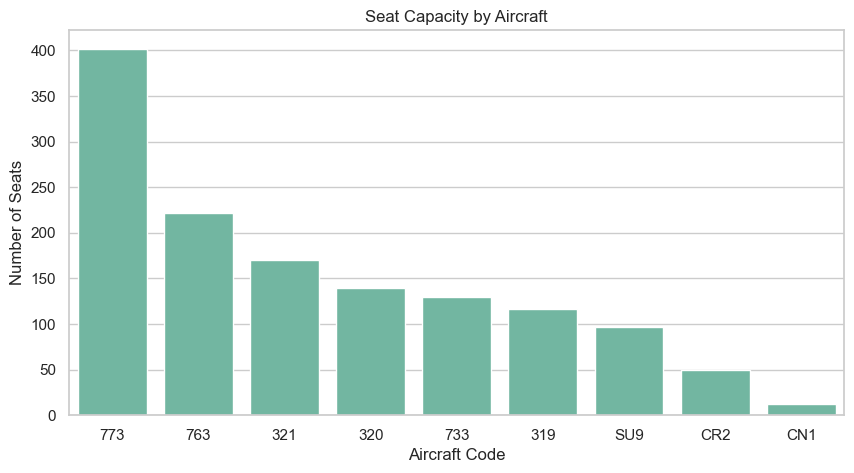

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=seat_capacity, x='aircraft_code', y='total_seats')
plt.title('Seat Capacity by Aircraft')
plt.xlabel('Aircraft Code')
plt.ylabel('Number of Seats')
plt.show()


**Observation:** Larger aircraft such as `773` and `763` have much higher seat capacity. These aircraft can bring more revenue, but they also carry more risk if many seats remain empty.


## 6. Business Question 2: How Did Bookings and Revenue Change Over Time?
This section shows the demand trend. If tickets and revenue rise together, the business is healthy. If tickets rise but revenue does not, it may mean lower average fares.


In [ ]:
booking_trend = pd.read_sql_query("""
    WITH daily_tickets AS (
        SELECT 
            SUBSTR(b.book_date, 1, 10) AS booking_date,
            COUNT(t.ticket_no) AS tickets_booked
        FROM bookings b
        JOIN tickets t
            ON b.book_ref = t.book_ref
        GROUP BY SUBSTR(b.book_date, 1, 10)
    ),
    daily_revenue AS (
        SELECT
            SUBSTR(book_date, 1, 10) AS booking_date,
            SUM(total_amount) AS total_revenue
        FROM bookings
        GROUP BY SUBSTR(book_date, 1, 10)
    )
    SELECT
        daily_tickets.booking_date,
        daily_tickets.tickets_booked,
        daily_revenue.total_revenue
    FROM daily_tickets
    JOIN daily_revenue
        ON daily_tickets.booking_date = daily_revenue.booking_date
    ORDER BY daily_tickets.booking_date;
""", connection)

booking_trend['booking_date'] = pd.to_datetime(booking_trend['booking_date'])
booking_trend.head()


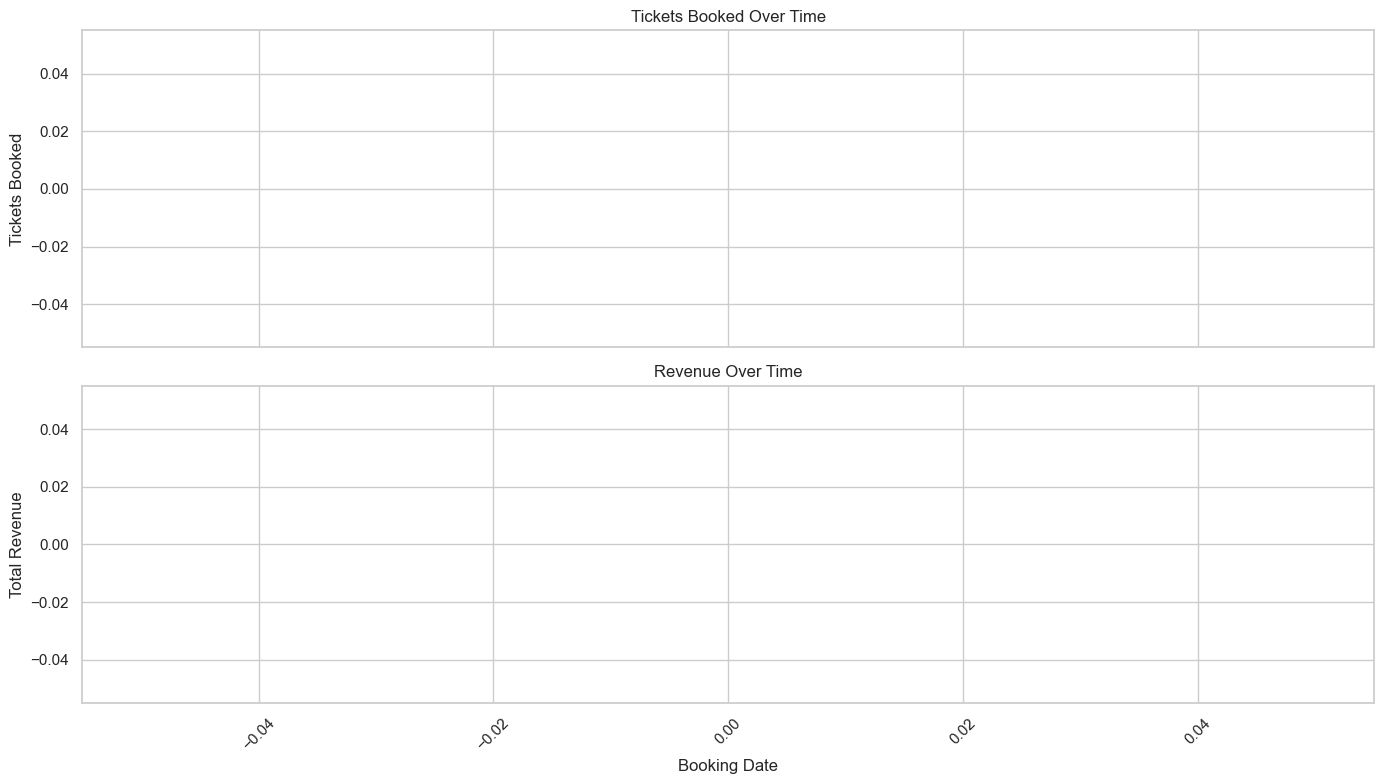

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sns.lineplot(data=booking_trend, x='booking_date', y='tickets_booked', marker='o', ax=axes[0])
axes[0].set_title('Tickets Booked Over Time')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tickets Booked')

sns.lineplot(data=booking_trend, x='booking_date', y='total_revenue', marker='o', ax=axes[1], color='teal')
axes[1].set_title('Revenue Over Time')
axes[1].set_xlabel('Booking Date')
axes[1].set_ylabel('Total Revenue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** This chart helps explain whether demand is stable, increasing, or decreasing. It also allows the airline to compare booking volume with money earned.


## 7. Business Question 3: Which Fare Conditions Earn More?
Fare condition tells us whether the passenger paid for Economy, Comfort, or Business. This helps identify which aircraft and fare types bring higher average ticket value.


In [11]:
avg_fare = pd.read_sql_query("""
    SELECT 
        f.aircraft_code,
        tf.fare_conditions,
        AVG(tf.amount) AS avg_ticket_amount
    FROM ticket_flights tf
    JOIN flights f
        ON tf.flight_id = f.flight_id
    GROUP BY f.aircraft_code, tf.fare_conditions
    ORDER BY f.aircraft_code, avg_ticket_amount DESC;
""", connection)

avg_fare


,aircraft_code,fare_conditions,avg_ticket_amount
0,319,Business,"113,550.56"
1,319,Economy,"38,311.40"
2,321,Business,"34,435.66"
3,321,Economy,"11,534.97"
4,733,Business,"41,865.63"
5,733,Economy,"13,985.15"
6,763,Business,"82,839.84"
7,763,Economy,"27,594.72"
8,773,Business,"57,779.91"
9,773,Comfort,"32,740.55"


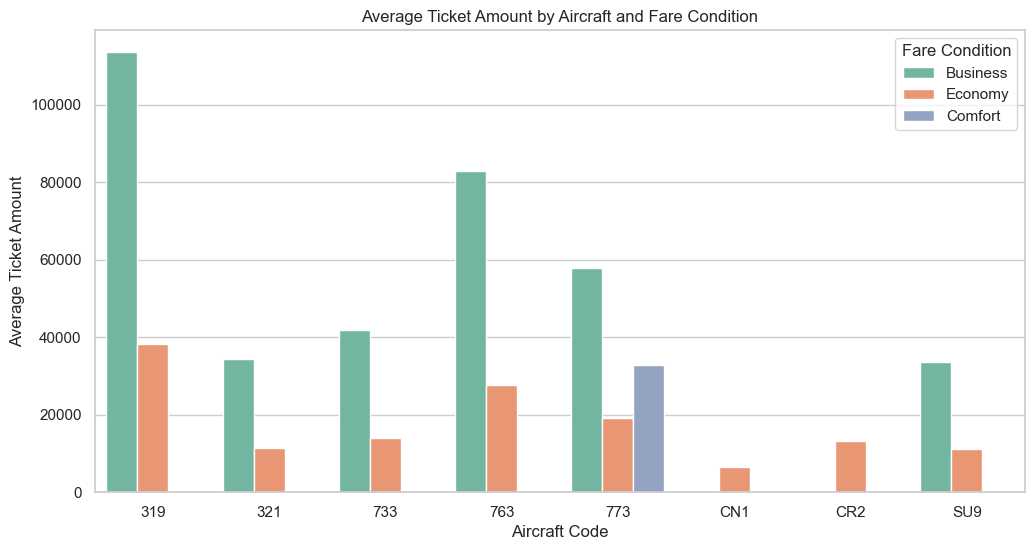

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_fare, x='aircraft_code', y='avg_ticket_amount', hue='fare_conditions')
plt.title('Average Ticket Amount by Aircraft and Fare Condition')
plt.xlabel('Aircraft Code')
plt.ylabel('Average Ticket Amount')
plt.legend(title='Fare Condition')
plt.show()


**Observation:** Business fares usually have higher average amounts. Aircraft with more premium seats can earn more per passenger, but they still need healthy occupancy.


## 8. Business Question 4: Which Aircraft Generate the Most Revenue?
Revenue alone does not tell the full story, but it shows which aircraft are contributing most to the business.


In [13]:
aircraft_revenue = pd.read_sql_query("""
    SELECT 
        f.aircraft_code,
        COUNT(tf.ticket_no) AS ticket_count,
        SUM(tf.amount) AS total_revenue,
        AVG(tf.amount) AS avg_revenue_per_ticket
    FROM ticket_flights tf
    JOIN flights f
        ON tf.flight_id = f.flight_id
    GROUP BY f.aircraft_code
    ORDER BY total_revenue DESC;
""", connection)

aircraft_revenue


,aircraft_code,ticket_count,total_revenue,avg_revenue_per_ticket
0,SU9,365698,5114484700,"13,985.54"
1,763,124774,4371277100,"35,033.56"
2,773,144376,3431205500,"23,765.76"
3,319,52853,2706163100,"51,201.69"
4,CR2,150122,1982760500,"13,207.66"
5,321,107129,1638164100,"15,291.51"
6,733,86102,1426552100,"16,568.16"
7,CN1,14672,96373800,"6,568.55"


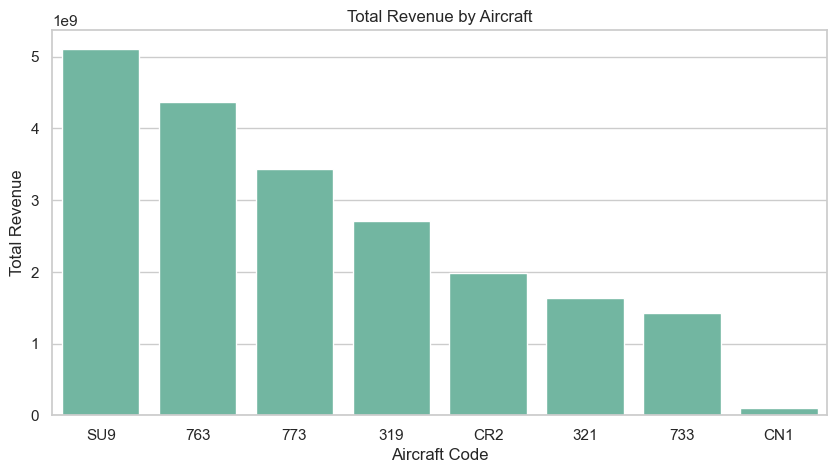

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(data=aircraft_revenue, x='aircraft_code', y='total_revenue')
plt.title('Total Revenue by Aircraft')
plt.xlabel('Aircraft Code')
plt.ylabel('Total Revenue')
plt.show()


**Observation:** High revenue can come from more tickets, higher fares, or both. This is why the next step studies occupancy rate.


## 9. Main Analysis: Occupancy Rate by Aircraft
Occupancy rate means:

**Occupancy Rate = Average Booked Seats per Flight / Total Seats in Aircraft**

A low occupancy rate means many seats are empty. Improving those flights is a clear opportunity for extra revenue.


In [15]:
occupancy_rate = pd.read_sql_query("""
    WITH booked_seats AS (
        SELECT 
            f.aircraft_code,
            f.flight_id,
            COUNT(bp.seat_no) AS booked_seats
        FROM flights f
        JOIN boarding_passes bp
            ON f.flight_id = bp.flight_id
        GROUP BY f.aircraft_code, f.flight_id
    ),
    aircraft_seats AS (
        SELECT 
            aircraft_code,
            COUNT(seat_no) AS total_seats
        FROM seats
        GROUP BY aircraft_code
    )
    SELECT 
        bs.aircraft_code,
        AVG(bs.booked_seats) AS avg_booked_seats,
        aircraft_seats.total_seats,
        AVG(bs.booked_seats) * 1.0 / aircraft_seats.total_seats AS occupancy_rate
    FROM booked_seats bs
    JOIN aircraft_seats
        ON bs.aircraft_code = aircraft_seats.aircraft_code
    GROUP BY bs.aircraft_code, aircraft_seats.total_seats
    ORDER BY occupancy_rate;
""", connection)

occupancy_rate['occupancy_percentage'] = occupancy_rate['occupancy_rate'] * 100
occupancy_rate


,aircraft_code,avg_booked_seats,total_seats,occupancy_rate,occupancy_percentage
0,CR2,21.48,50,0.43,42.97
1,319,53.58,116,0.46,46.19
2,CN1,6.00,12,0.50,50.04
3,763,113.94,222,0.51,51.32
4,321,88.81,170,0.52,52.24
5,SU9,56.81,97,0.59,58.57
6,733,80.26,130,0.62,61.73
7,773,264.93,402,0.66,65.90


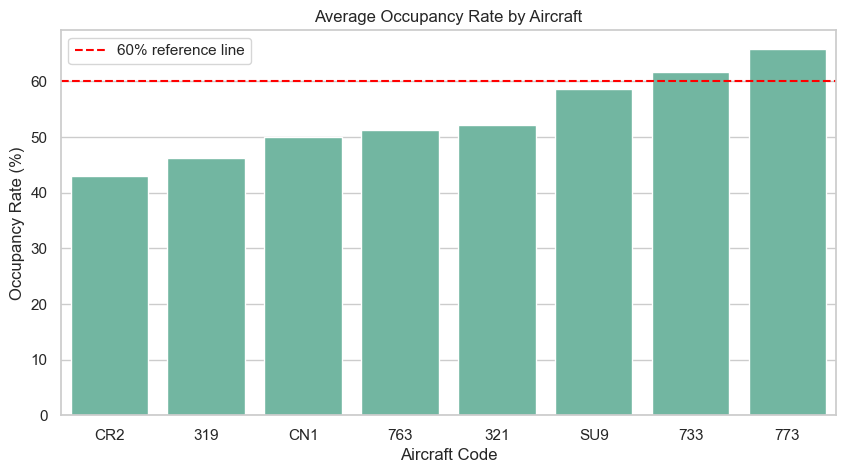

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(data=occupancy_rate, x='aircraft_code', y='occupancy_percentage')
plt.axhline(60, color='red', linestyle='--', label='60% reference line')
plt.title('Average Occupancy Rate by Aircraft')
plt.xlabel('Aircraft Code')
plt.ylabel('Occupancy Rate (%)')
plt.legend()
plt.show()


**Observation:** Aircraft below the reference line have more unused capacity. These aircraft should be studied first for pricing, route planning, or promotion decisions.


## 10. Low Occupancy Focus
Now we combine occupancy and revenue. This gives a more useful business view than looking at either number alone.


In [17]:
aircraft_performance = occupancy_rate.merge(aircraft_revenue, on='aircraft_code')
aircraft_performance = aircraft_performance.sort_values('occupancy_rate')

aircraft_performance[[
    'aircraft_code',
    'avg_booked_seats',
    'total_seats',
    'occupancy_percentage',
    'ticket_count',
    'total_revenue',
    'avg_revenue_per_ticket'
]]


,aircraft_code,avg_booked_seats,total_seats,occupancy_percentage,ticket_count,total_revenue,avg_revenue_per_ticket
0,CR2,21.48,50,42.97,150122,1982760500,"13,207.66"
1,319,53.58,116,46.19,52853,2706163100,"51,201.69"
2,CN1,6.00,12,50.04,14672,96373800,"6,568.55"
3,763,113.94,222,51.32,124774,4371277100,"35,033.56"
4,321,88.81,170,52.24,107129,1638164100,"15,291.51"
5,SU9,56.81,97,58.57,365698,5114484700,"13,985.54"
6,733,80.26,130,61.73,86102,1426552100,"16,568.16"
7,773,264.93,402,65.90,144376,3431205500,"23,765.76"


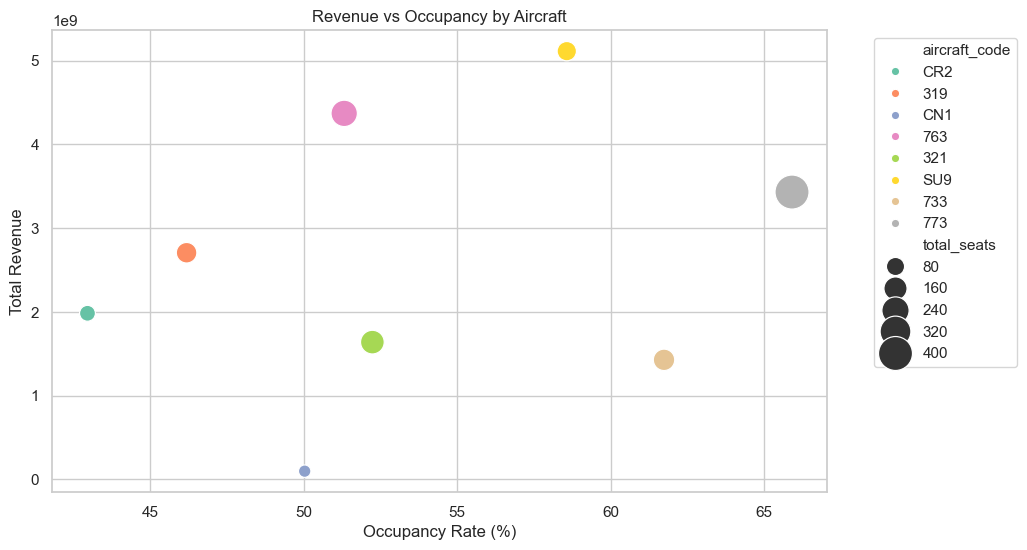

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=aircraft_performance,
    x='occupancy_percentage',
    y='total_revenue',
    size='total_seats',
    hue='aircraft_code',
    sizes=(80, 600)
)
plt.title('Revenue vs Occupancy by Aircraft')
plt.xlabel('Occupancy Rate (%)')
plt.ylabel('Total Revenue')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


**How to read this chart:**

- Aircraft on the left have lower occupancy.
- Aircraft higher on the chart generate more revenue.
- Bigger points represent aircraft with more seats.

The best improvement opportunities are usually aircraft with lower occupancy but meaningful revenue potential.


## 11. What If Occupancy Improves by 10%?
This is a simple business simulation. If each aircraft improves its occupancy by 10%, we estimate the possible increase in revenue.

This is not a perfect prediction, because real revenue also depends on routes, ticket prices, season, and demand. But it is useful for showing the value of reducing empty seats.


In [19]:
improvement = aircraft_performance.copy()

improvement['target_occupancy_rate'] = (improvement['occupancy_rate'] * 1.10).clip(upper=1)
improvement['target_occupancy_percentage'] = improvement['target_occupancy_rate'] * 100
improvement['projected_revenue'] = improvement['total_revenue'] * (improvement['target_occupancy_rate'] / improvement['occupancy_rate'])
improvement['additional_revenue'] = improvement['projected_revenue'] - improvement['total_revenue']
improvement['extra_passengers_per_flight'] = improvement['avg_booked_seats'] * 0.10

improvement[[
    'aircraft_code',
    'occupancy_percentage',
    'target_occupancy_percentage',
    'extra_passengers_per_flight',
    'total_revenue',
    'projected_revenue',
    'additional_revenue'
]].sort_values('additional_revenue', ascending=False)


,aircraft_code,occupancy_percentage,target_occupancy_percentage,extra_passengers_per_flight,total_revenue,projected_revenue,additional_revenue
5,SU9,58.57,64.43,5.68,5114484700,"5,625,933,170.00","511,448,470.00"
3,763,51.32,56.46,11.39,4371277100,"4,808,404,810.00","437,127,710.00"
7,773,65.90,72.49,26.49,3431205500,"3,774,326,050.00","343,120,550.00"
1,319,46.19,50.81,5.36,2706163100,"2,976,779,410.00","270,616,310.00"
0,CR2,42.97,47.26,2.15,1982760500,"2,181,036,550.00","198,276,050.00"
4,321,52.24,57.46,8.88,1638164100,"1,801,980,510.00","163,816,410.00"
6,733,61.73,67.91,8.03,1426552100,"1,569,207,310.00","142,655,210.00"
2,CN1,50.04,55.04,0.60,96373800,"106,011,180.00","9,637,380.00"


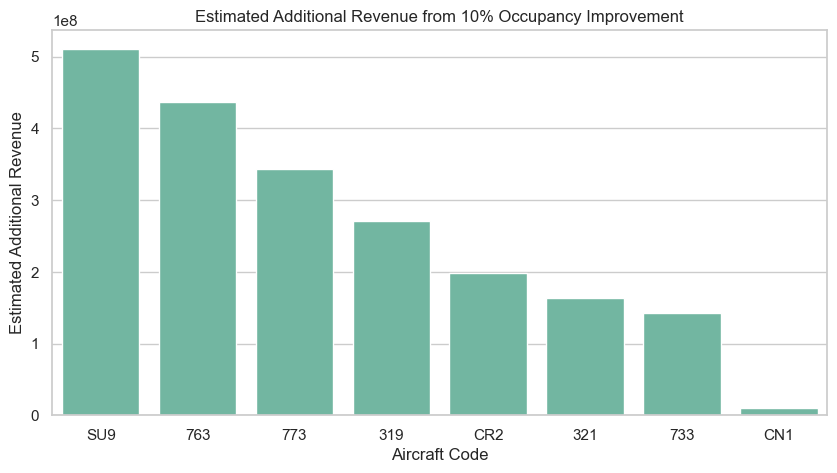

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=improvement.sort_values('additional_revenue', ascending=False),
    x='aircraft_code',
    y='additional_revenue'
)
plt.title('Estimated Additional Revenue from 10% Occupancy Improvement')
plt.xlabel('Aircraft Code')
plt.ylabel('Estimated Additional Revenue')
plt.show()


## 12. Business Recommendations
Based on the analysis, the airline can focus on these actions:

1. **Target low-occupancy aircraft first** because they have the most empty-seat opportunity.
2. **Use promotions on weaker routes or periods** instead of discounting all flights.
3. **Review aircraft assignment** so very large aircraft are not used on routes with weak demand.
4. **Protect high-value fare classes** because Business and Comfort tickets increase average revenue.
5. **Track occupancy regularly** because small improvements can create meaningful revenue growth.


## Final Conclusion
This project shows that airline profitability is not only about selling more tickets. It is about selling the right number of seats on the right aircraft at the right price.

The occupancy analysis gives a clear business direction: flights with lower occupancy should be reviewed first. Even a simple 10% improvement in occupancy can increase revenue because the aircraft is already scheduled and many operating costs are already fixed.

So, the main insight is:

**Reducing empty seats is one of the simplest ways for the airline to improve revenue without immediately adding new flights or aircraft.**
